# Solution: Optimiser les hyperparamètres avec GridSearchCV

Utiliser [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html?highlight=gridsearch#sklearn.model_selection.GridSearchCV) pour optimiser les hyperparamètres d'un modèle

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
from yellowbrick.model_selection import LearningCurve
from yellowbrick.model_selection import ValidationCurve
from sklearn.model_selection import GridSearchCV


In [2]:
bikeshare = pd.read_csv("../../data/bikeshare.csv")
bikeshare.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feelslike,humidity,windspeed,riders
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [3]:
# On supprime la colonne label des données
X = bikeshare.drop("riders", axis=1)

# on récupère la colonne label dans une variable séparée
y = bikeshare["riders"]

In [4]:
# TODO: Extraire les données de train et de test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2
)

## Etudier l'effet individuel des hyperparamètres de l'algorithme choisi.

On pourra exploiter les [courbes de validation](https://www.scikit-yb.org/en/latest/api/model_selection/validation_curve.html#) de `yellowbrick`

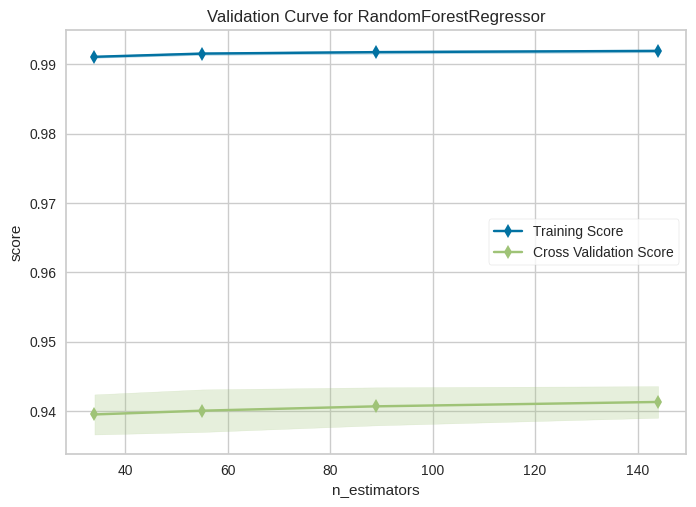

In [5]:
# TODO: Etude du paramètre n_estimators

viz = ValidationCurve(
    RandomForestRegressor(n_jobs=-1), param_name="n_estimators",
    param_range=[34, 55, 89, 144], cv=5, scoring="r2"
)

viz.fit(X_train, y_train)
viz.show();

`n_estimators` semble avoir peu d'effet. Nous allons garder la valeur par défaut pour l'instant

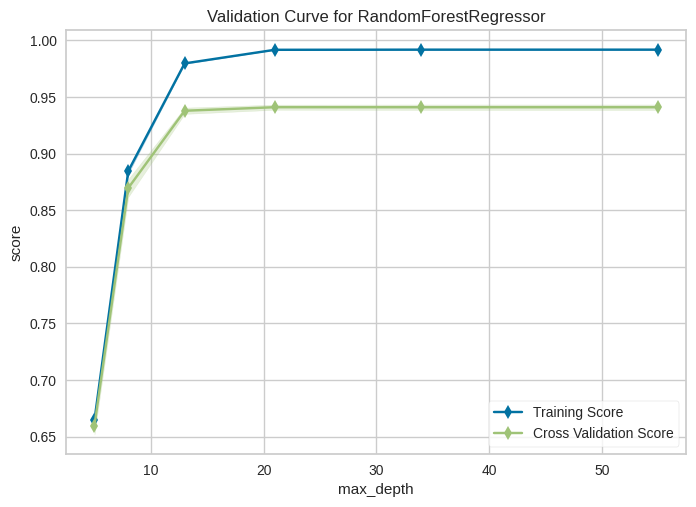

In [6]:
# TODO: Etude du paramètre max_depth

viz = ValidationCurve(
    RandomForestRegressor(n_jobs=-1, random_state=2), param_name="max_depth",
    param_range=[5, 8, 13, 21, 34, 55], cv=5, scoring="r2"
)

viz.fit(X_train, y_train)
viz.show();

Les valeurs au dessus de 13 atteignent un plateau.
L'overfitting constaté ne s'acompagne pas d'une agravation de la variance.
On gardera donc la valeur par défaut.

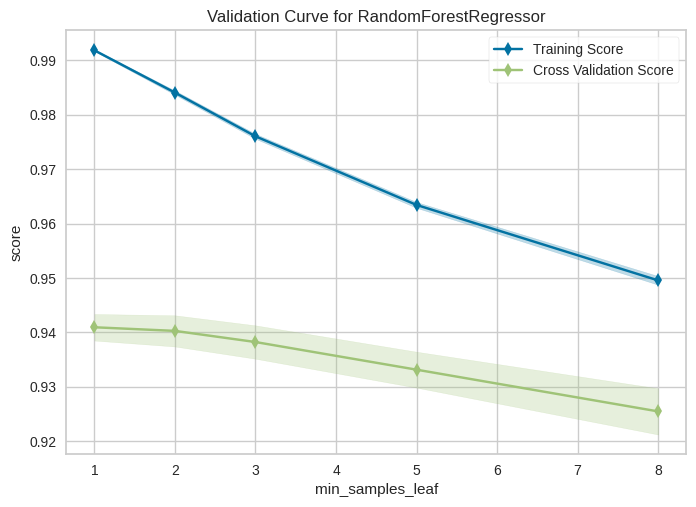

In [7]:
# TODO: Etude du paramètre min_samples_leaf

viz = ValidationCurve(
    RandomForestRegressor(n_jobs=-1, random_state=2), param_name="min_samples_leaf",
    param_range=[1, 2, 3, 5, 8], cv=5, scoring="r2"
)

viz.fit(X_train, y_train)
viz.show();

On serait tenté de ne garder que les valeurs en dessous de 3, mais la diminution de la variance (gap) incite à garder des valeurs supérieures (par exemple jusqu'à 5)

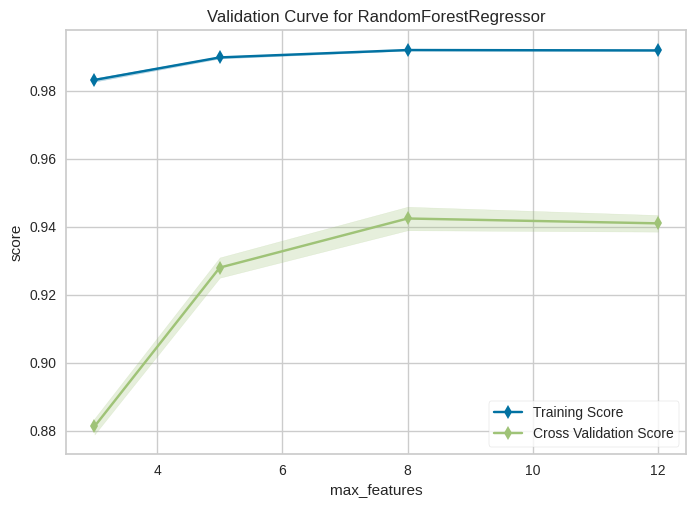

In [8]:
# TODO: Etude du paramètre max_features

viz = ValidationCurve(
    RandomForestRegressor(n_jobs=-1, random_state=2), param_name="max_features",
    param_range=[3, 5, 8, 12], cv=5, scoring="r2"
)

viz.fit(X_train, y_train)
viz.show();

On gardera les valeurs comprises entre 8 et 12

## Utiliser [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html?highlight=gridsearch#sklearn.model_selection.GridSearchCV) pour choisir les "meilleurs" hyperparamètres


In [9]:
# TODO: Recherche d'un "optimum" grâce à GridSearchCV

# grid_search_reg = ...

param_grid = [
    {
        "max_features": [8, 9, 10, 12], "min_samples_leaf": [1, 2, 3, 5]
    },
]

grid_search_reg = GridSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=2), param_grid, cv=5, scoring="r2",
    return_train_score=True
)
grid_search_reg.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=2),
             param_grid=[{'max_features': [8, 9, 10, 12],
                          'min_samples_leaf': [1, 2, 3, 5]}],
             return_train_score=True, scoring='r2')

In [10]:
# Exploitation du modèle obtenu sur les données ...

grid_search_reg.best_estimator_

RandomForestRegressor(max_features=9, n_jobs=-1, random_state=2)

In [11]:
def get_sorted_cv_results(grid_search_reg):
    cv_results = grid_search_reg.cv_results_
    selected_cv_results = zip(
        cv_results["params"],
        cv_results["mean_test_score"],
        cv_results["std_test_score"],
        cv_results["mean_train_score"],
        cv_results["std_train_score"]
    )

    def get_mean_test_score(cv_result):
        return cv_result[1]

    sorted_cv_results = sorted(selected_cv_results, key=get_mean_test_score, reverse=True)
    return sorted_cv_results

# Afficher les résultats
def display_cv_results(grid_search_reg):
    sorted_cv_results = get_sorted_cv_results(grid_search_reg)
    for params, mean_test_score, std_test_score, mean_train_score, std_train_score in sorted_cv_results:
        print(
            params,
            mean_test_score,
            std_test_score,
            mean_train_score,
            std_train_score,
        )

In [12]:
# TODO: afficher les resultats de GridSearchCV

display_cv_results(grid_search_reg)

{'max_features': 9, 'min_samples_leaf': 1} 0.943455544394347 0.00286939945890067 0.9920726709070887 0.00019176994642825583
{'max_features': 10, 'min_samples_leaf': 1} 0.9429977752799003 0.003184518496375536 0.9920529486521396 0.00013884884276564512
{'max_features': 8, 'min_samples_leaf': 1} 0.9423777694791721 0.003454688044686784 0.9919327778230654 0.00016507027990776926
{'max_features': 9, 'min_samples_leaf': 2} 0.942158354560083 0.0033902446981304494 0.983695480664354 0.00038011433114399566
{'max_features': 10, 'min_samples_leaf': 2} 0.9420504729162943 0.0034885421065645387 0.9840256572602504 0.000306534171516866
{'max_features': 12, 'min_samples_leaf': 1} 0.9409504706300951 0.0024394630783509505 0.9918195474552004 0.00016162707875180086
{'max_features': 8, 'min_samples_leaf': 2} 0.9406713336626007 0.0037862403821329045 0.9828520610534731 0.00035739591141785735
{'max_features': 12, 'min_samples_leaf': 2} 0.9402850746128717 0.0028619286976081793 0.9840521119530374 0.000376817255059835

## Discussion

- Etrudiez les résultats précédents.
- A-t-on résolu avec `GridSearchCV` les problèmes que pose l'optimisation des hyperparamètres ?